## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 2

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from scipy.stats import norm
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_2\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_2\initial_outputs.npy")

# INPUT file storing historical inputs 2D array (n, dim)
input_file = r"initial_data\function_2\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_2\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 22 points:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.8582913  0.96968786]
 [0.55406231 0.98808433]
 [0.65236203 0.29543538]
 [0.090909   0.747474  ]
 [0.99165605 0.04068865]
 [0.0010769  0.04302203]
 [0.97267897 0.37162255]
 [0.99262478 0.99870368]
 [0.323232   0.545454  ]
 [0.         0.999999  ]
 [0.999999   0.696969  ]
 [0.595959   0.        ]]
Historical OUTPUT contains 22 points:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.02276738  0.00855723
  0.39482706 -0.13129975  0.08256396 -0.00632619 -0.10505341 -0.02581706
  0.02670775  0.09949192 -0.00703271  0.01723797]


In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 2
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

# INPUT file storing historical inputs 2D array (n, dim)
input_file = r"initial_data\function_2\inputs.npy"

# INPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_2\outputs.npy"

# Grid density for grid search
grid_density = 100
use_grid_search = True
# Acquisition type
acquisition_type = 'ei'    # 'ucb' or 'ei'

In [4]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, bounds, n_candidates, beta):
    # 20260428, add white noise
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 100.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-8, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.05)
    model.fit(X, y)
    # Generate candidate points
    candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define a grid research function to find the point that maximizes the acquisition function.

In [5]:
# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    # 20260428, add white noise
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

Load historical data
Loaded 22 points. And the historical OUTPUT:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.02276738  0.00855723
  0.39482706 -0.13129975  0.08256396 -0.00632619 -0.10505341 -0.02581706
  0.02670775  0.09949192 -0.00703271  0.01723797]
Current best output: 0.611205


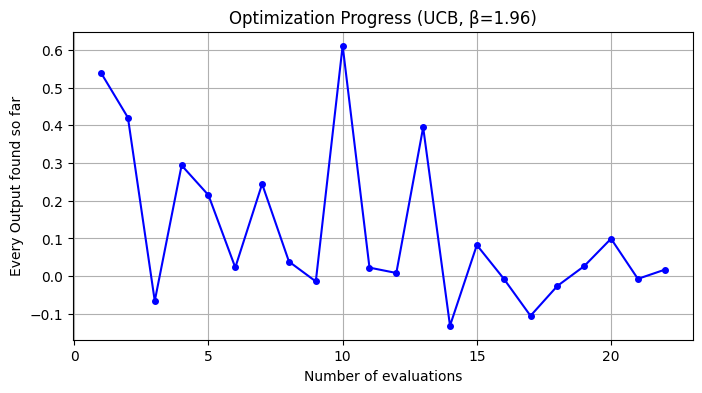

In [6]:
# 3. Load historical data and view current status
X, y = load_data()

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

In [7]:
# 4. Recommend the next point to submit
if use_grid_search:
    print("Output has been unimproved over several queries. Use grid research for exploration.")
    x_next, best_acquisition_value = grid_search_acquisition(X, y, bounds, grid_density, acquisition_type)
    print(f"Grid search selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    x_next, best_acquisition_value = suggest_next_point(X, y, bounds, n_candidates, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Output has been unimproved over several queries. Use grid research for exploration.
Use Expected Improvement (EI) acquisition function.
Predicted mean = 0.482206, std = 0.428063, UCB = 1.321208
Grid search selected point with acquisition value: 0.110197
The 13th recommended input point:
[0.80808  0.161616]
0.80808-0.161616


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)

KeyboardInterrupt: Interrupted by user